In [1]:
import numpy as np
import os 
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.linalg import eigh, inv
import pandas as pd
from nki_rs2_eeg.config import (SESSION_ID, TASK_ID, RUN_ID, DERIVATIVES_DIR, CONCAT_DATA_DIR, RAW_DATA_DIR)

In [2]:
channel_files = list(DERIVATIVES_DIR.rglob("sub*/ses-MOBI1A/eeg/sub-*_ses-MOBI1A_task-passivepresent_run-1_channels.tsv"))
# Combine all channel files into a single DataFrame
channels_df = pd.concat([pd.read_csv(file, sep='\t') for file in channel_files])
sub_ids = [file.parts[-4] for file in channel_files]
channels_df['subject'] = np.repeat(sub_ids, 64)
channels_df['is_bad'] = channels_df['status'] == 'bad'
# for each subject get the sum of the boolean columns
channels = channels_df.groupby('subject')[channels_df.select_dtypes(include='bool').columns].sum()

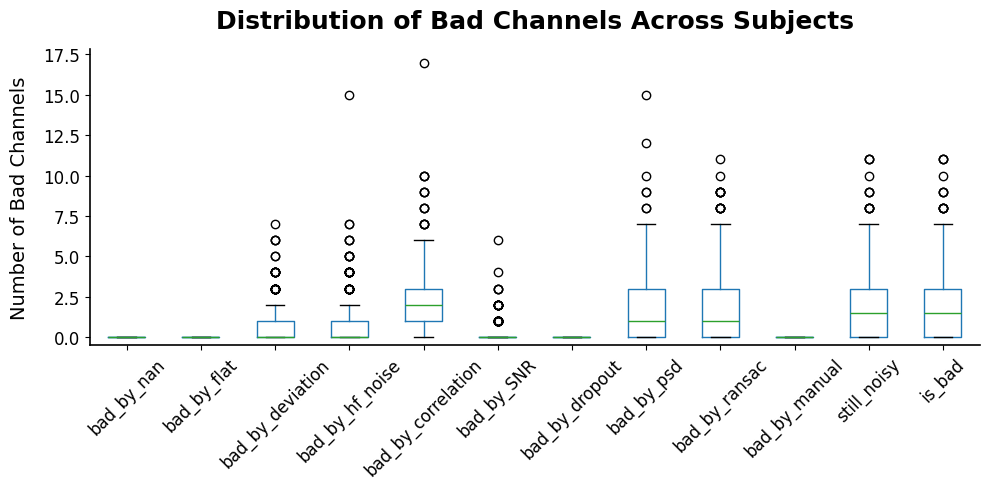

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.style.use('default')

fig, ax = plt.subplots(figsize=(10, 5))

# Plot boxplot on the axes
channels.boxplot(ax=ax)

# ── Styling ────────────────────────────────────────────────────────────────────
# White background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Lift the y-axis floor so 0 sits above the spine
ax.set_ylim(bottom=-0.5)
ax.spines['bottom'].set_position(('data', -0.5))  # spine stays at plot edge

# Presentation fonts
ax.set_title('Distribution of Bad Channels Across Subjects', fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel('Number of Bad Channels', fontsize=14, labelpad=10)
ax.set_xlabel('')

ax.tick_params(axis='both', labelsize=12)
ax.tick_params(axis='x', rotation=45)

# Clean spines — keep bottom and left only
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# plot the distibution of bad channels across subjects with mean and 2 standard deviations
plt.figure(figsize=(10, 6))
plt.hist(channels.is_bad, bins=20, alpha=0.7, color='blue')
plt.axvline(channels.is_bad.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(channels.is_bad.mean() + 2*channels.is_bad.std(), color='green', linestyle='dashed', linewidth=1)
plt.axvline(channels.is_bad.mean() - 2*channels.is_bad.std(), color='green', linestyle='dashed', linewidth=1)
plt.title('Distribution of Bad Channels Across Subjects')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()


In [ ]:
# how many subjects have more than 6 bad channels?
print(f"{(channels.is_bad > 6).sum()} subjects have more than 6 bad channels")

subject_exclusions = channels[channels.is_bad > 6].index.tolist()
subject_exclusions

In [ ]:
subject_isc = np.load(DERIVATIVES_DIR / "sub-ALL_ses-MOBI1A_task-passivepresent_run-1_isc_per_subject.npy")
subject_order = np.load(DERIVATIVES_DIR / "sub-ALL_ses-MOBI1A_task-passivepresent_run-1_isc_sub_order.npy")
subject_age = pd.read_csv("/home/bgonzalez/NKI_RS2_EEG/data/RS2_age.csv", sep=',')

subject_age.head()

In [ ]:
print('hey')